In [14]:
from typing import Annotated
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict
from langchain_anthropic import AnthropicLLM, ChatAnthropic
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.tools import Tool

from langgraph.checkpoint.memory import MemorySaver
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver
import nest_asyncio
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser
import textwrap


In [2]:
load_dotenv(override=True)

True

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

In [22]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Send a push notification via Pushover"""
    requests.post(pushover_url, data={"token": pushover_token, "user": pushover_user, "message": text})

tool_push = Tool(
    name="send_push_notification",
    func=push,
    description="Send a push notification via Pushover",
)


### Install Playwright

### Using asyncio to run nested loops

In [23]:

nest_asyncio.apply()

In [42]:
async_browser = create_async_playwright_browser(headless=False)
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()

In [25]:
for tool in tools:
    print(f"{tool.name}: {tool.description}")

click_element: Click on an element with the given CSS selector
navigate_browser: Navigate a browser to the specified URL
previous_webpage: Navigate back to the previous page in the browser history
extract_text: Extract all the text on the current webpage
extract_hyperlinks: Extract all hyperlinks on the current webpage
get_elements: Retrieve elements in the current web page matching the given CSS selector
current_webpage: Returns the URL of the current page


In [44]:
tool_dict = {tool.name: tool for tool in tools}

navigate_tool = tool_dict.get("navigate_browser")
extract_text_tool = tool_dict.get("extract_text")

await navigate_tool.arun({"url": "https://www.ndtv.com"})
text = await extract_text_tool.arun({})

In [45]:
print(textwrap.fill(text))

Get Latest News, India News, Breaking News, Today's News - NDTV.com 0
arrow-down search bell top-nav right-arrow Advertisement Live TV
Latest India India All India News India Global Diaspora South Latest
Top Court Slams Maneka Gandhi For Stray Dogs Remark, Flags "Body
Language" Woman, 19, Killed As Speeding Jaguar Crashes While
Overtaking Truck In Noida Builder Arrested After Noida Techie Drowns
In Water-Filled Pit A Fall From Grace: Top Karnataka Cop Ramachandra
Rao's Controversies Assam's Kokrajhar Tense After Mob Kills Man Over
Cattle Theft Suspicion World Videos Opinion Cities Metros Bengaluru
Chennai Delhi Mumbai Other Cities Ahmedabad Allahabad Amritsar Bhopal
Bhubaneshwar Chandigarh Ghaziabad Goa Gurgaon Guwahati Hyderabad
Jaipur Kanpur Kolkata Lucknow Noida Patna Pune Srinagar
Thiruvananthapuram Beeps Davos New Education Education Exams School
Campus Study Abroad Web Stories Latest Maharashtra SSC Hall Ticket
2026 Out, Download Here, Exam From Feb 20 IIT Delhi Executive Course


In [46]:
all_tools = tools + [tool_push]

In [47]:
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(all_tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

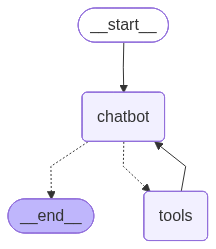

In [48]:
graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=all_tools))
graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [49]:
config = {"configurable": {"thread_id": "11"}}

async def chat(user_input: str, history):
    result = await graph.ainvoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content

gr.ChatInterface(chat).launch()

* Running on local URL:  http://127.0.0.1:7864
* To create a public link, set `share=True` in `launch()`.
